# Проект: классификация

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing  import LabelEncoder
from sklearn import linear_model 
from sklearn import tree 
from sklearn import ensemble 
from sklearn import metrics 
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split 
from sklearn.feature_selection import SelectKBest, f_classif

## Часть 1. Знакомство с данными, обработка пропусков и выбросов

### Задание 1

In [2]:
df = pd.read_csv('bank_fin.csv', sep = ';')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11137 non-null  str  
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(6), str(11)
memory usage: 1.4 MB


### Задание 2

In [4]:
print(df['job'].unique())

<StringArray>
[       'admin.',    'technician',      'services',    'management',
       'retired',   'blue-collar',    'unemployed',  'entrepreneur',
     'housemaid',       'unknown', 'self-employed',       'student']
Length: 12, dtype: str


### Задание 3

In [5]:
def make_convert(row):
    if pd.isna(row) or row == 'unknown':
        return np.nan
    # Удаляем пробелы и знак доллара
    row = str(row).replace(' ', '').replace('$', '')
    # Заменяем запятую на точку для перевода во float
    row = row.replace(',', '.')
    return float(row)

# Применяем функцию к столбцу balance
df['balance'] = df['balance'].apply(make_convert)

# Считаем среднее значение, округляя до 3 знаков
mean_balance = df['balance'].mean()
print(round(mean_balance, 3))


1529.129


### Задание 4

In [9]:
# 1. Заполняем пропуски медианой
df['balance'] = df['balance'].fillna(df['balance'].median())

# 2. Считаем новое среднее значение
new_mean_balance = df['balance'].mean()

# 3. Выводим результат с округлением до 3 знаков
print(round(new_mean_balance, 3))


1526.936


### Задание 5

In [10]:
# 1. Заменяем 'unknown' на модальные значения в признаках job и education
# Находим моду (может быть несколько, берем первую [0])
job_mode = df['job'].mode()[0]
education_mode = df['education'].mode()[0]

# Проводим замену
df['job'] = df['job'].apply(lambda x: job_mode if x == 'unknown' else x)
df['education'] = df['education'].apply(lambda x: education_mode if x == 'unknown' else x)

# 2. Рассчитываем средний баланс для самой популярной работы и образования
# (management и secondary — самые частые в этом датасете)
mask = (df['job'] == job_mode) & (df['education'] == education_mode)
result_mean = df[mask]['balance'].mean()

print(f"Мода работы: {job_mode}")
print(f"Мода образования: {education_mode}")
print(f"Средний баланс: {round(result_mean, 3)}")


Мода работы: management
Мода образования: secondary
Средний баланс: 1598.883


### Задание 6

In [11]:
# Рассчитываем квантили и IQR
q1 = df['balance'].quantile(0.25)
q3 = df['balance'].quantile(0.75)
iqr = q3 - q1

# Вычисляем границы по методу Тьюки
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"Нижняя граница: {round(lower_bound)}")
print(f"Верхняя граница: {round(upper_bound)}")

# Фильтруем данные, чтобы оставить только значения внутри границ
df = df[(df['balance'] >= lower_bound) & (df['balance'] <= upper_bound)]
print(f"Новый размер датасета: {df.shape}")


Нижняя граница: -2241
Верхняя граница: 4063
Новый размер датасета: (10105, 17)


## Часть 2:  Разведывательный анализ

### Задание 1

Количество клиентов:
deposit
no     5424
yes    4681
Name: count, dtype: int64

Частота (доли классов):
deposit
no     0.536764
yes    0.463236
Name: proportion, dtype: float64


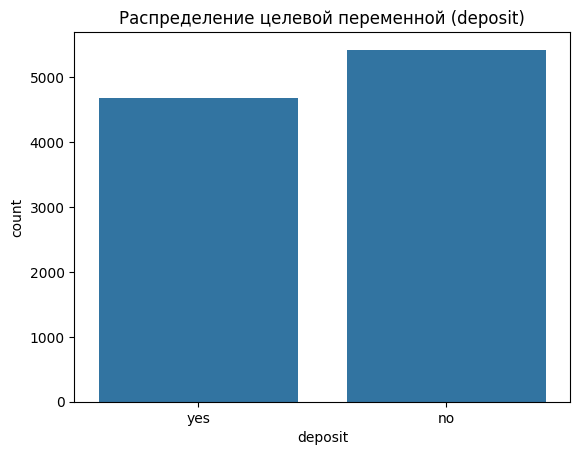

In [12]:
# Посчитаем количество и частоту каждого класса
deposit_counts = df['deposit'].value_counts()
deposit_frequencies = df['deposit'].value_counts(normalize=True)

print("Количество клиентов:")
print(deposit_counts)
print("\nЧастота (доли классов):")
print(deposit_frequencies)

# Визуализация
sns.countplot(data=df, x='deposit')
plt.title('Распределение целевой переменной (deposit)')
plt.show()


### Задания 2 и 3

,age,balance,day,duration,campaign,pdays,previous
count,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000
mean,40.895497,807.653538,15.590302,368.742603,2.517170,51.319644,0.816230
std,11.734931,994.151966,8.441510,346.651524,2.707159,109.644179,2.243795
min,18.000000,-2049.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,95.000000,8.000000,137.000000,1.000000,-1.000000,0.000000
50%,38.000000,445.000000,15.000000,252.000000,2.000000,-1.000000,0.000000
75%,48.000000,1227.000000,22.000000,490.000000,3.000000,2.000000,1.000000
max,95.000000,4063.000000,31.000000,3881.000000,43.000000,854.000000,58.000000


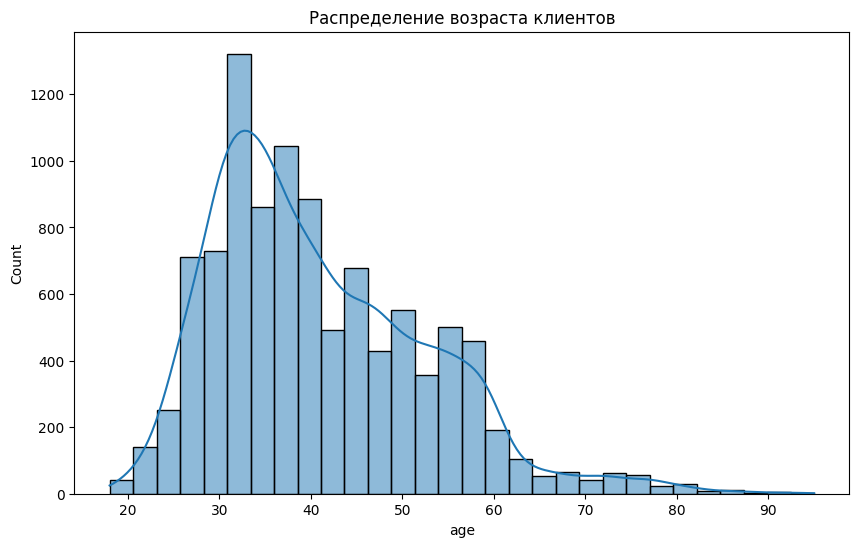

Максимальный возраст клиента: 95


In [13]:
# Описательные статистики для числовых признаков
numeric_stats = df.describe()
display(numeric_stats)

# Визуализация распределения возраста
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Распределение возраста клиентов')
plt.show()

# Максимальный возраст
max_age = df['age'].max()
print(f"Максимальный возраст клиента: {max_age}")


### Задания 4 и 5

,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,10105,10105,10105,10105,10105,10105,10105,10105,10105,10105
unique,11,3,3,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2315,5715,5517,9939,5243,8712,7283,2617,7570,5424


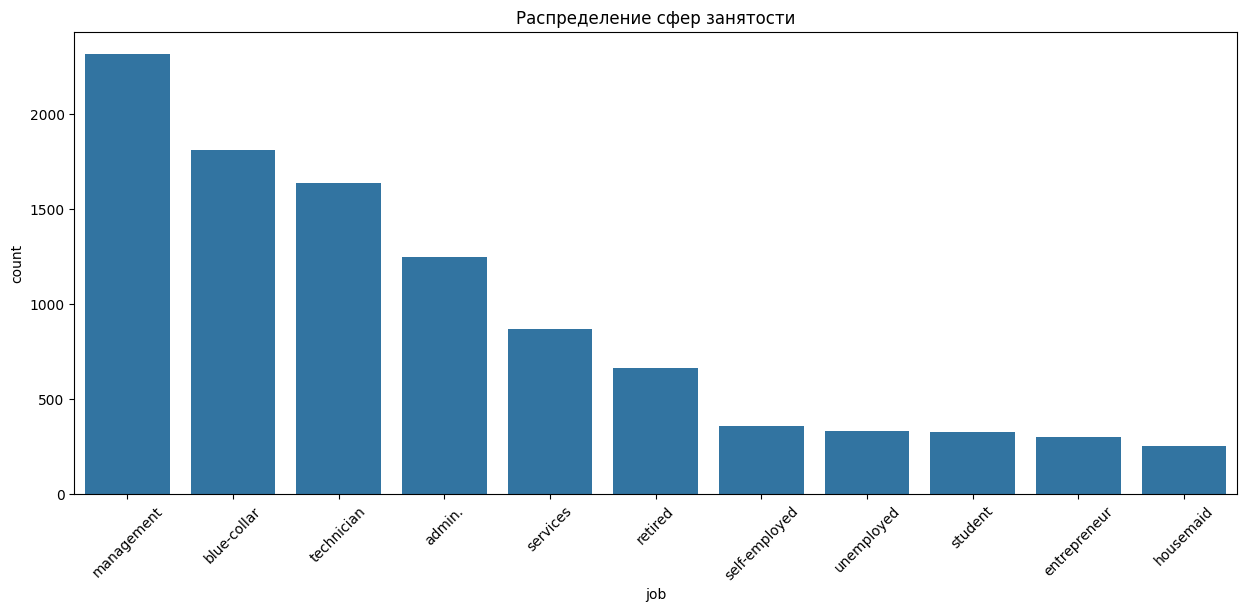

Количество месяцев проведения кампании: 12
Уникальные месяцы: <StringArray>
['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'jan', 'feb', 'mar', 'apr',
 'sep']
Length: 12, dtype: str
Количество сфер занятости: 11


In [14]:
# Описательные статистики для категориальных признаков
cat_stats = df.describe(include='object')
display(cat_stats)

# Визуализация самого частого признака - Сферы занятости
plt.figure(figsize=(15, 6))
sns.countplot(data=df, x='job', order=df['job'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Распределение сфер занятости')
plt.show()

# Проверка месяцев
months_count = df['month'].nunique()
print(f"Количество месяцев проведения кампании: {months_count}")
print(f"Уникальные месяцы: {df['month'].unique()}")

# Количество сфер занятости
jobs_count = df['job'].nunique()
print(f"Количество сфер занятости: {jobs_count}")


### Задание 6

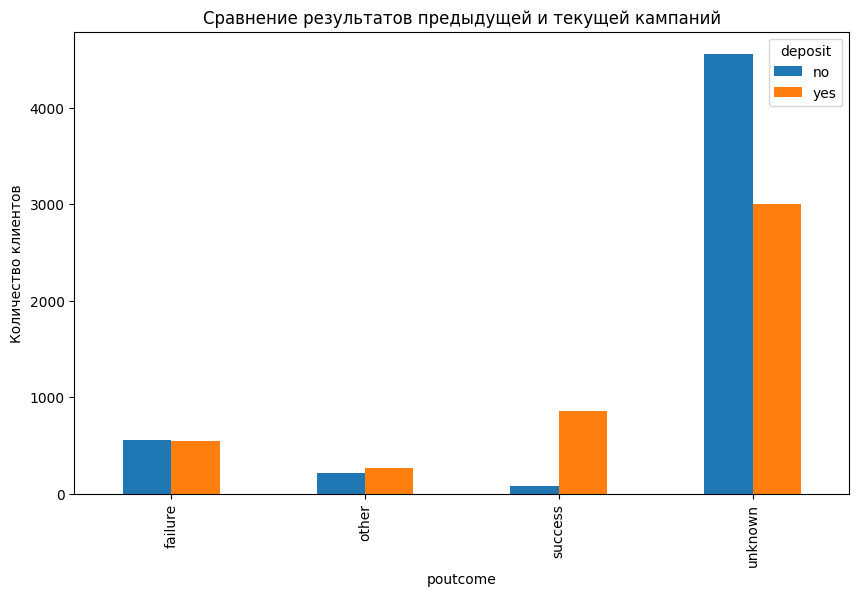

deposit,no,yes
poutcome,,
failure,562,547
other,216,265
success,84,861
unknown,4562,3008


In [15]:
# Строим таблицу сопряженности
poutcome_deposit = pd.crosstab(df['poutcome'], df['deposit'])

# Визуализация для наглядности
poutcome_deposit.plot(kind='bar', stacked=False, figsize=(10, 6))
plt.title('Сравнение результатов предыдущей и текущей кампаний')
plt.ylabel('Количество клиентов')
plt.show()

display(poutcome_deposit)


### Задание 7

Процент неудач по месяцам:
month
may    0.678640
jan    0.608150
jul    0.589563
nov    0.584615
aug    0.559567
jun    0.548913
feb    0.455571
apr    0.381928
oct    0.185075
sep    0.165468
mar    0.101266
dec    0.096774
Name: no, dtype: float64


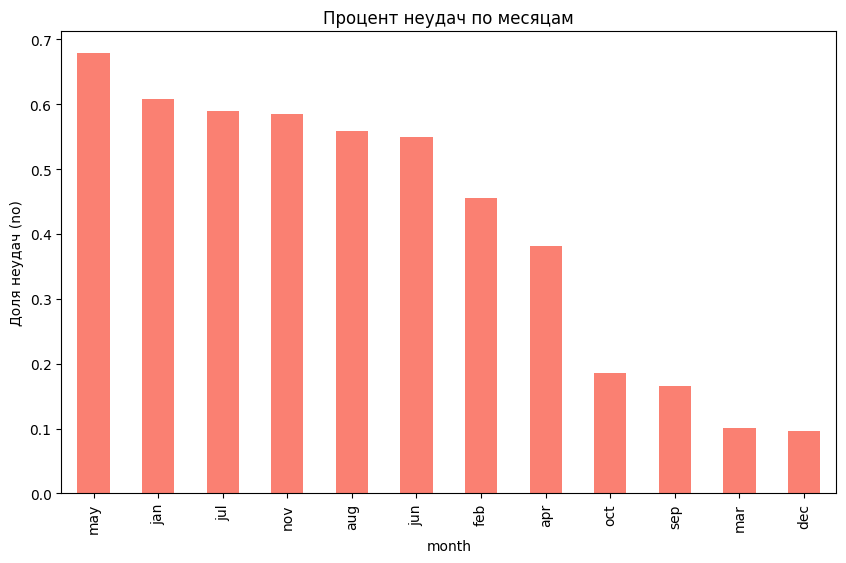

In [16]:
# Строим таблицу сопряженности месяца и результата
month_deposit = pd.crosstab(df['month'], df['deposit'], normalize='index')

# Сортируем по проценту неудач ('no') по убыванию
month_failure_rate = month_deposit['no'].sort_values(ascending=False)

print("Процент неудач по месяцам:")
print(month_failure_rate)

# Визуализация
month_failure_rate.plot(kind='bar', color='salmon', figsize=(10, 6))
plt.title('Процент неудач по месяцам')
plt.ylabel('Доля неудач (no)')
plt.show()


### Задание 8

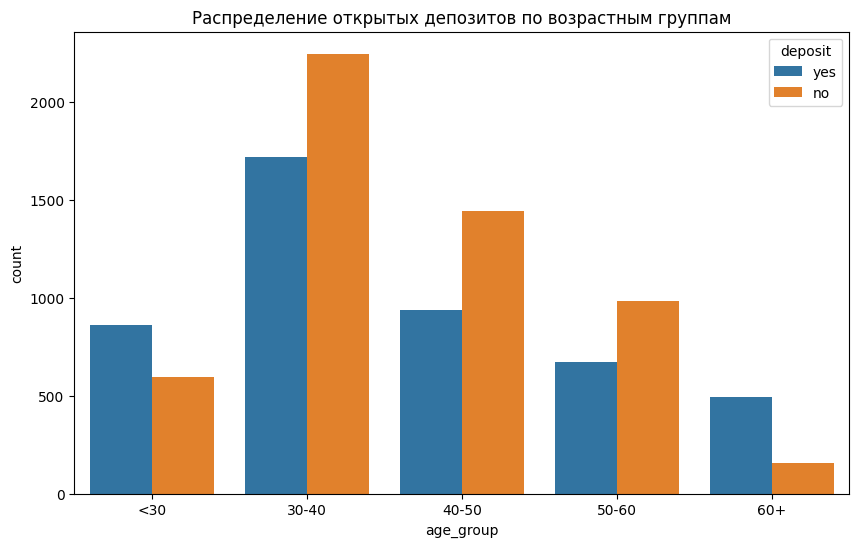

deposit,no,yes
age_group,,
30-40,0.566776,0.433224
40-50,0.606213,0.393787
50-60,0.594921,0.405079
60+,0.240429,0.759571
<30,0.408247,0.591753


In [17]:
# Создаем функцию для группировки возраста
def get_age_group(age):
    if age < 30:
        return '<30'
    elif 30 <= age < 40:
        return '30-40'
    elif 40 <= age < 50:
        return '40-50'
    elif 50 <= age < 60:
        return '50-60'
    else:
        return '60+'

# Применяем функцию к столбцу age
df['age_group'] = df['age'].apply(get_age_group)

# Визуализируем влияние возраста на открытие депозита
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='age_group', hue='deposit', 
              order=['<30', '30-40', '40-50', '50-60', '60+'])
plt.title('Распределение открытых депозитов по возрастным группам')
plt.show()

# Также полезно посмотреть на процент успеха в каждой группе
age_success = pd.crosstab(df['age_group'], df['deposit'], normalize='index')
display(age_success)


### Задания 9 и 10

AttributeError: 'Axes' object has no attribute 'set_tick_params'

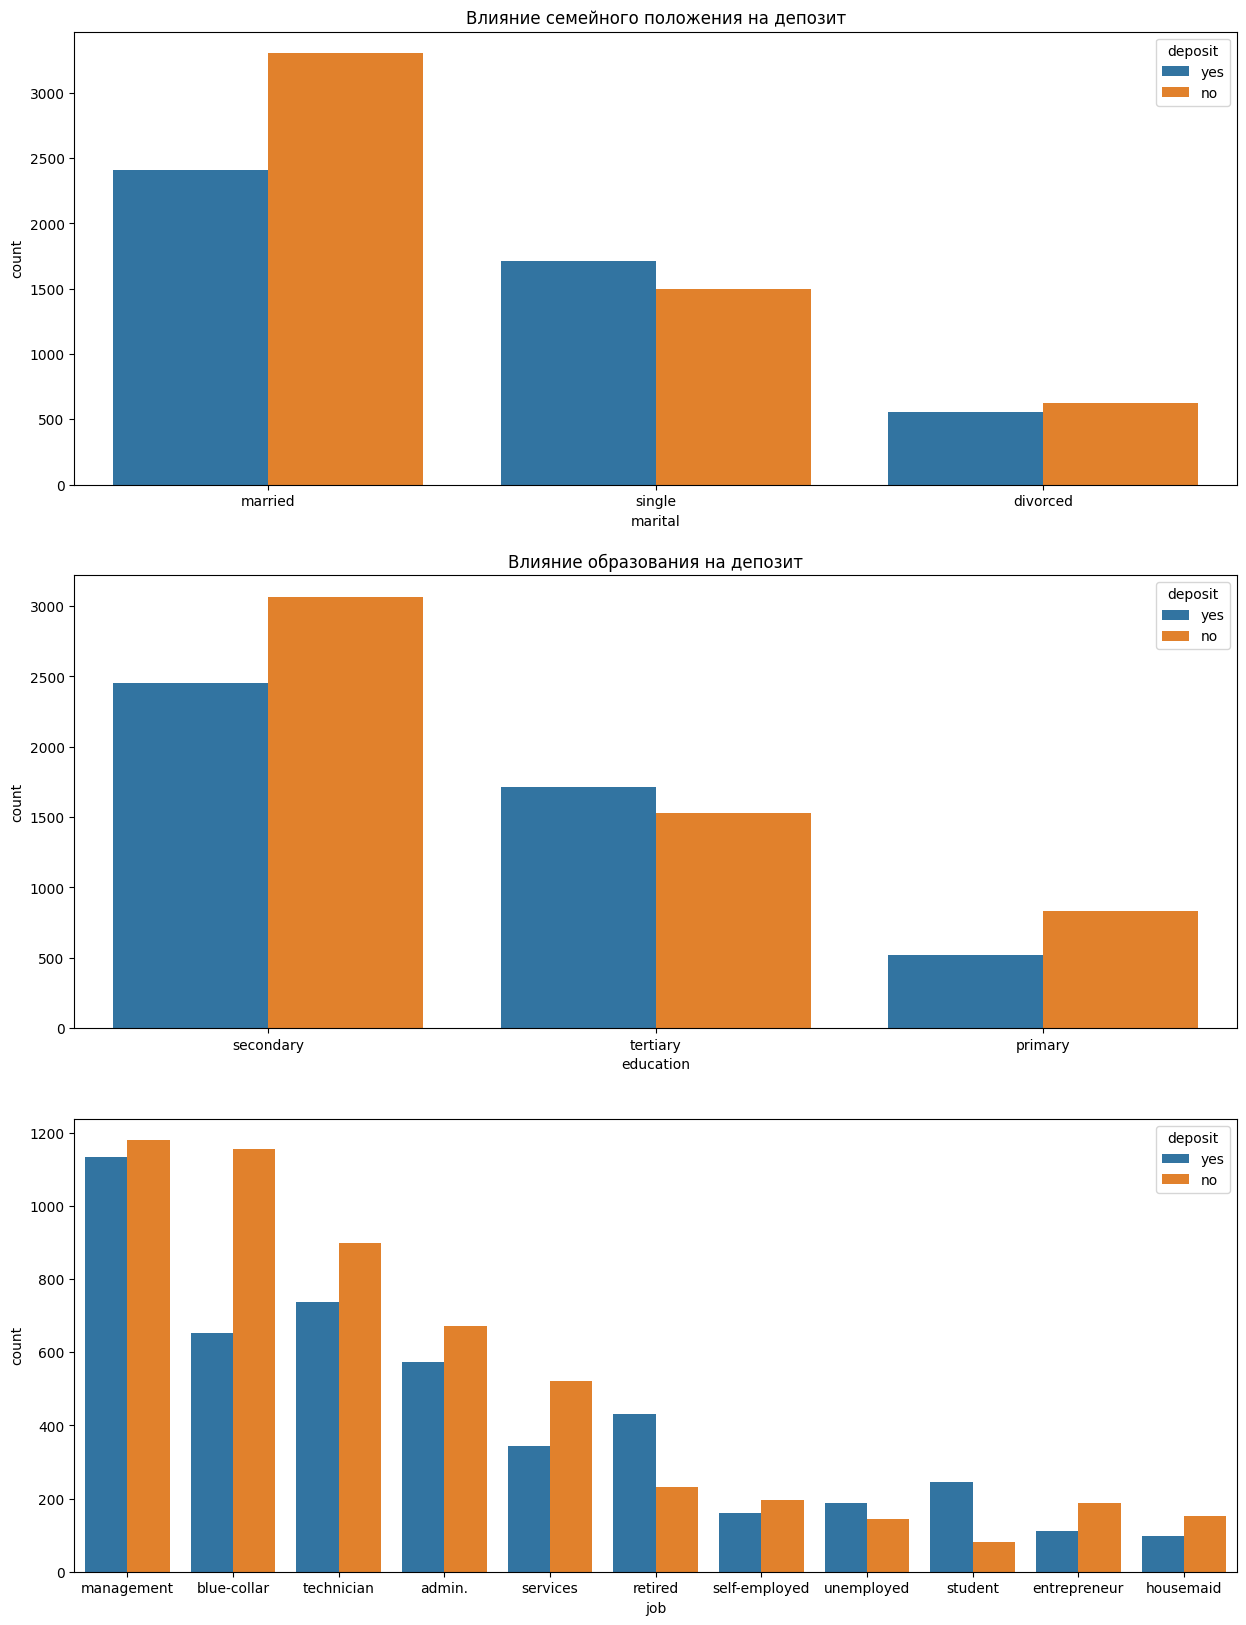

In [18]:
# Настроим сетку графиков
fig, ax = plt.subplots(3, 1, figsize=(15, 20))

# 1. Семейное положение
sns.countplot(data=df, x='marital', hue='deposit', ax=ax[0])
ax[0].set_title('Влияние семейного положения на депозит')

# 2. Уровень образования
sns.countplot(data=df, x='education', hue='deposit', ax=ax[1])
ax[1].set_title('Влияние образования на депозит')

# 3. Сфера занятости
sns.countplot(data=df, x='job', hue='deposit', ax=ax[2], order=df['job'].value_counts().index)
ax[2].set_tick_params(axis='x', rotation=45)
ax[2].set_title('Влияние сферы занятости на депозит')

plt.tight_layout()
plt.show()


### Задание 11

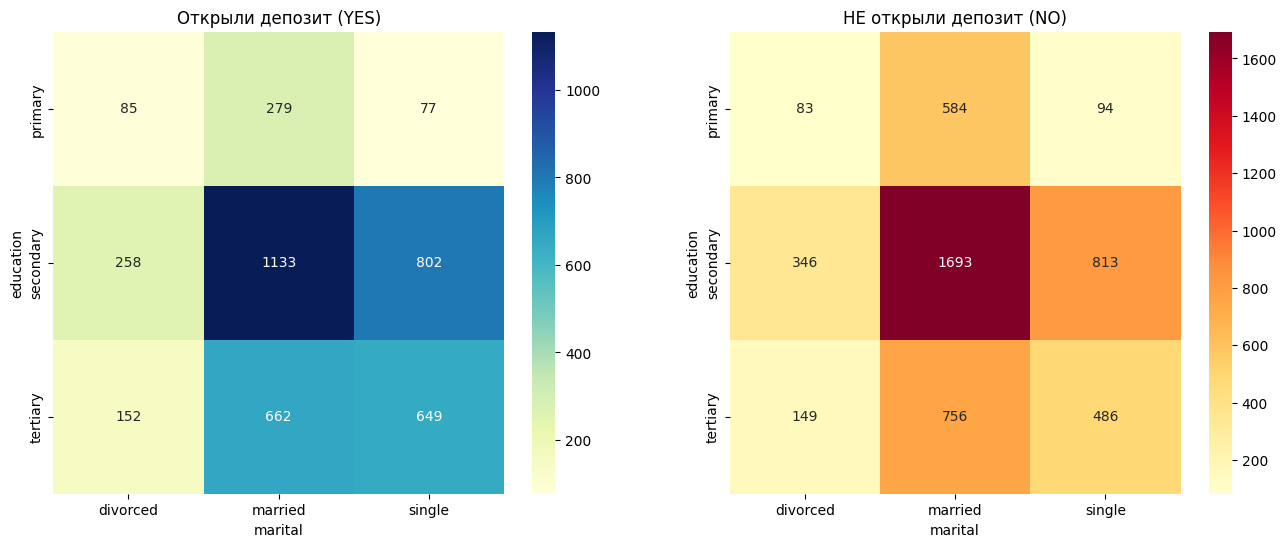

Самый массовый сегмент (YES):
1133

Самый массовый сегмент (NO):
1693


In [25]:
q1 = df['balance'].quantile(0.25)
q3 = df['balance'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Фильтруем датафрейм
df = df[(df['balance'] >= lower_bound) & (df['balance'] <= upper_bound)]

# 1. Фильтруем тех, кто открыл депозит, и тех, кто нет
df_yes = df[df['deposit'] == 'yes']
df_no = df[df['deposit'] == 'no']

# 2. Создаем сводные таблицы (индексы - образование, колонки - семейное положение)
pivot_yes = pd.crosstab(df_yes['education'], df_yes['marital'])
pivot_no = pd.crosstab(df_no['education'], df_no['marital'])

# 3. Визуализация
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(pivot_yes, annot=True, fmt='d', cmap='YlGnBu', ax=ax[0])
ax[0].set_title('Открыли депозит (YES)')
sns.heatmap(pivot_no, annot=True, fmt='d', cmap='YlOrRd', ax=ax[1])
ax[1].set_title('НЕ открыли депозит (NO)')
plt.show()

# Выведем значения для проверки самого крупного сегмента
print("Самый массовый сегмент (YES):")
print(pivot_yes.max().max())
print("\nСамый массовый сегмент (NO):")
print(pivot_no.max().max())



## Часть 3: преобразование данных

### Задание 1

In [29]:
# 1. Убедитесь, что 'unknown' заменен на 'secondary' (мода)
df['education'] = df['education'].apply(lambda x: 'secondary' if x == 'unknown' else x)

# 2. Примените LabelEncoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['education'] = le.fit_transform(df['education'])

# 3. Посчитайте сумму
print(df['education'].sum())


10753


### Задания 2 и 3

In [30]:
from sklearn.preprocessing import LabelEncoder

# 1. Кодируем возрастные группы с помощью LabelEncoder
le = LabelEncoder()
df['age_group'] = le.fit_transform(df['age_group'])

# 2. Перекодируем целевую переменную deposit (yes -> 1, no -> 0)
df['deposit'] = df['deposit'].apply(lambda x: 1 if x == 'yes' else 0)

# 3. Вычисляем стандартное отклонение для deposit
deposit_std = df['deposit'].std()
print(f"Стандартное отклонение deposit: {round(deposit_std, 3)}")


Стандартное отклонение deposit: 0.498


### Задание 4

In [31]:
# Список бинарных признаков
binary_cols = ['default', 'housing', 'loan']

# Кодируем (yes -> 1, no -> 0)
for col in binary_cols:
    df[col] = df[col].apply(lambda x: 1 if x == 'yes' else 0)

# Считаем средние значения и их сумму
sum_of_means = df['default'].mean() + df['housing'].mean() + df['loan'].mean()

print(f"Среднее для default: {df['default'].mean()}")
print(f"Среднее для housing: {df['housing'].mean()}")
print(f"Среднее для loan: {df['loan'].mean()}")
print(f"Сумма средних: {round(sum_of_means, 3)}")


Среднее для default: 0.01801999780243929
Среднее для housing: 0.4901659158334249
Среднее для loan: 0.1460279090209867
Сумма средних: 0.654


In [33]:
# Список номинальных признаков
nominal_cols = ['job', 'marital', 'contact', 'month', 'poutcome']

# Создаем дамми-переменные
df_dummies = pd.get_dummies(df[nominal_cols])

# Объединяем с основным датасетом (до удаления оригинальных колонок)
df_with_dummies = pd.concat([df, df_dummies], axis=1)

# Считаем количество признаков (минус целевая переменная 'deposit')
features_count = df_with_dummies.drop(['deposit'], axis=1).shape[1]

print(f"Общее количество признаков: {features_count}")


Общее количество признаков: 50


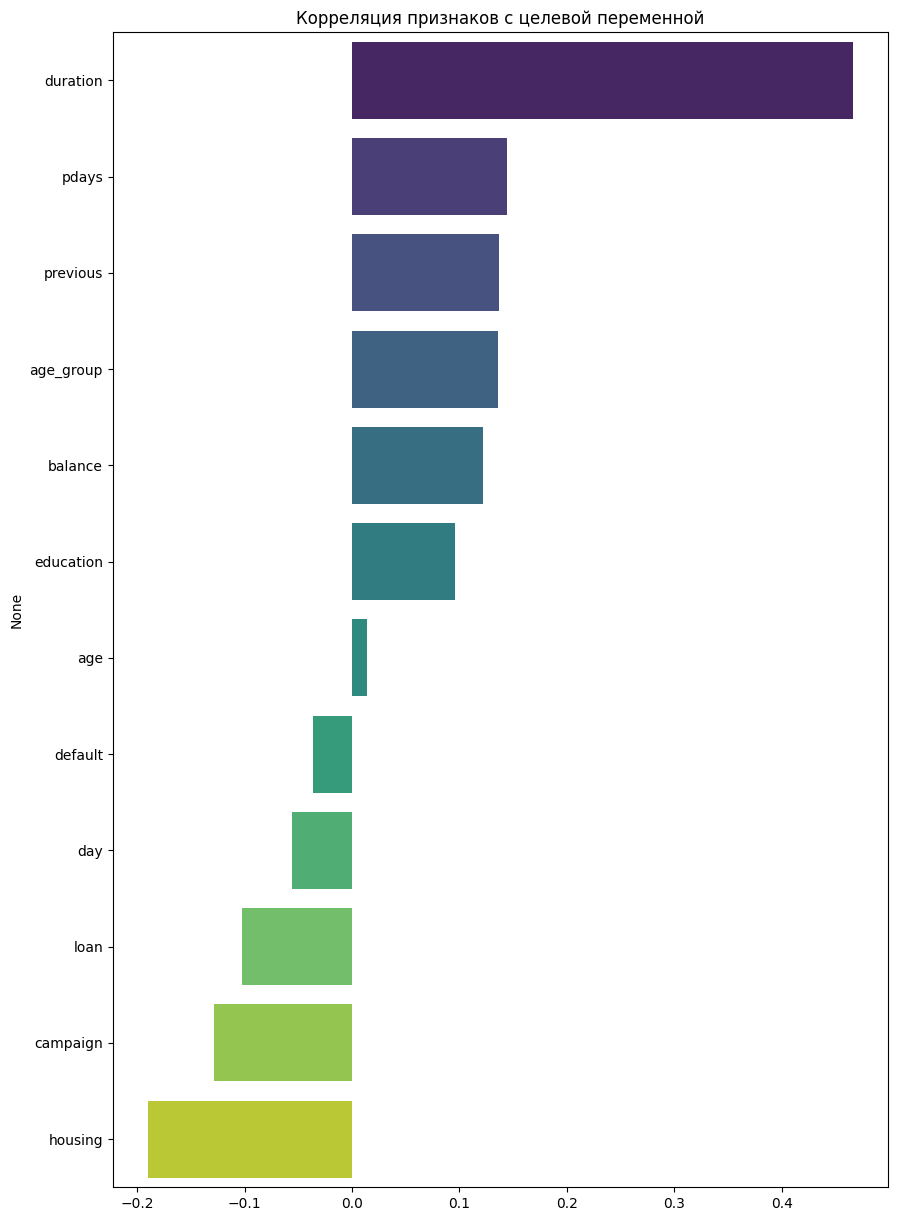

Топ признаков для ранжирования:
duration     0.466023
housing      0.190065
pdays        0.144197
previous     0.137043
age_group    0.136179
Name: deposit, dtype: float64


In [35]:
# 1. Считаем корреляцию только для числовых признаков
corr = df.corr(numeric_only=True)

# 2. Выделяем связь с депозитом
deposit_corr = corr['deposit'].drop('deposit').sort_values(ascending=False)

# 3. Визуализируем
plt.figure(figsize=(10, 15))
sns.barplot(x=deposit_corr.values, y=deposit_corr.index, palette='viridis')
plt.title('Корреляция признаков с целевой переменной')
plt.show()

# Топ-4 по силе связи (могут быть как положительные, так и отрицательные)
print("Топ признаков для ранжирования:")
print(deposit_corr.abs().sort_values(ascending=False).head(5))


### Задания 7 и 8

In [36]:
X = df.drop(['deposit'], axis=1)
y = df['deposit']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)

In [37]:
print(f"Размер тестовой выборки (количество строк): {X_test.shape[0]}")

Размер тестовой выборки (количество строк): 3004


In [38]:
# Рассчитываем среднее для y_test
test_mean = y_test.mean()

print(f"Среднее значение deposit на тестовой выборке: {round(test_mean, 2)}")


Среднее значение deposit на тестовой выборке: 0.45


### Задание 9

In [40]:
# 1. Оставляем в X только числовые признаки
# Это удалит 'job', 'marital', 'contact', 'month', 'poutcome' в их текстовом виде
X_train_numeric = X_train.select_dtypes(include=['number'])
X_test_numeric = X_test.select_dtypes(include=['number'])

# 2. Теперь запускаем SelectKBest
selector = SelectKBest(score_func=f_classif, k=15)
selector.fit(X_train_numeric, y_train)

# 3. Получаем названия отобранных признаков
selected_features = X_train_numeric.columns[selector.get_support()]

print("Отобранные признаки (топ-15):")
print(selected_features.tolist())

# Проверка списка из задания
check_list = ['month_mar', 'month_may', 'month_oct', 'month_sep', 'month_jan']
missing = [m for m in check_list if m not in selected_features]
print(f"\nПризнак из списка, который НЕ попал в топ-15: {missing}")


Отобранные признаки (топ-15):
['age', 'education', 'default', 'balance', 'housing', 'loan', 'day', 'duration', 'campaign', 'pdays', 'previous', 'age_group']

Признак из списка, который НЕ попал в топ-15: ['month_mar', 'month_may', 'month_oct', 'month_sep', 'month_jan']


### Задание 10

In [41]:
from sklearn.preprocessing import MinMaxScaler

# 1. Оставляем только 15 отобранных признаков
X_train_final = X_train_numeric[selected_features]
X_test_final = X_test_numeric[selected_features]

# 2. Инициализируем и обучаем MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

# 3. Рассчитываем среднее арифметическое для первого столбца тестовой выборки
# Первый столбец имеет индекс 0
first_col_mean = X_test_scaled[:, 0].mean()

print(f"Название первого признака: {selected_features[0]}")
print(f"Среднее арифметическое первого столбца в тесте: {round(first_col_mean, 2)}")


Название первого признака: age
Среднее арифметическое первого столбца в тесте: 0.3


# Часть 4: Решение задачи классификации: логистическая регрессия и решающие деревья

### Задание 1

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

# 1. Обучаем логистическую регрессию
log_reg = LogisticRegression(
    solver='sag', 
    random_state=42, 
    max_iter=1000
)
log_reg.fit(X_train_scaled, y_train)

# 2. Делаем предсказание на тестовой выборке
y_test_pred = log_reg.predict(X_test_scaled)

# 3. Рассчитываем Accuracy
accuracy_test = metrics.accuracy_score(y_test, y_test_pred)

print(f"Accuracy на тестовой выборке: {round(accuracy_test, 2)}")


Accuracy на тестовой выборке: 0.79


### Задания 2,3,4

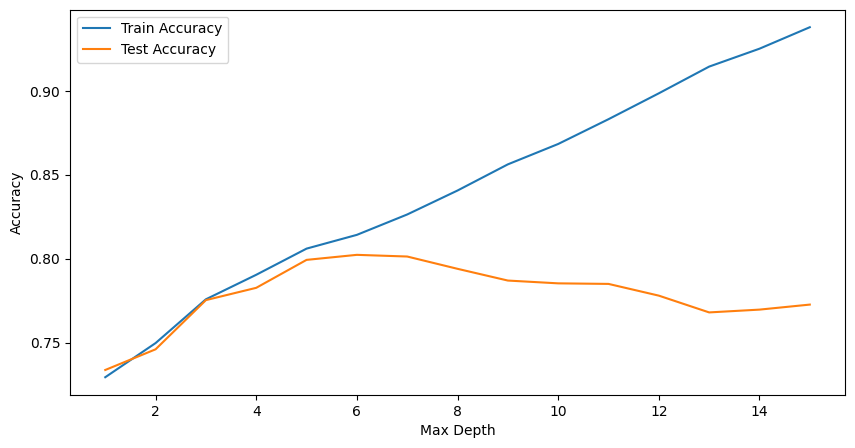

Максимальная точность на тесте: 0.8


In [45]:
# Создаем списки для хранения точности
train_scores = []
test_scores = []

# Перебираем глубину от 1 до 15
for depth in range(1, 16):
    dt = DecisionTreeClassifier(
        criterion='entropy', 
        max_depth=depth, 
        random_state=42
    )
    dt.fit(X_train_scaled, y_train)
    
    # Считаем точность
    train_scores.append(metrics.accuracy_score(y_train, dt.predict(X_train_scaled)))
    test_scores.append(metrics.accuracy_score(y_test, dt.predict(X_test_scaled)))

# Визуализируем результаты для наглядности
plt.figure(figsize=(10, 5))
plt.plot(range(1, 16), train_scores, label='Train Accuracy')
plt.plot(range(1, 16), test_scores, label='Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Находим максимальное значение на тесте
print(f"Максимальная точность на тесте: {round(max(test_scores), 2)}")


### Задание 5

In [46]:
from sklearn.model_selection import GridSearchCV

# 1. Задаем сетку параметров
param_grid = {
    'min_samples_split': [2, 5, 7, 10],
    'max_depth': [3, 5, 7]
}

# 2. Инициализируем поиск (используем то же дерево с энтропией)
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(criterion='entropy', random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5 # кросс-валидация
)

# 3. Обучаем
grid_search.fit(X_train_scaled, y_train)

# 4. Получаем лучшую модель и считаем метрику на тесте
best_dt = grid_search.best_estimator_
y_test_pred = best_dt.predict(X_test_scaled)
accuracy_test = metrics.accuracy_score(y_test, y_test_pred)

print(f"Наилучшие параметры: {grid_search.best_params_}")
print(f"Accuracy на тестовой выборке: {round(accuracy_test, 2)}")


Наилучшие параметры: {'max_depth': 7, 'min_samples_split': 2}
Accuracy на тестовой выборке: 0.8


# Часть 5: Решение задачи классификации: ансамбли моделей и построение прогноза

### Задание 1

In [48]:
from sklearn.ensemble import RandomForestClassifier

# 1. Обучаем случайный лес
rf = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    min_samples_leaf=5,
    max_depth=10,
    random_state=42
)
rf.fit(X_train_scaled, y_train)

# 2. Делаем предсказание
y_test_pred = rf.predict(X_test_scaled)

# 3. Считаем метрики
accuracy_rf = metrics.accuracy_score(y_test, y_test_pred)
recall_rf = metrics.recall_score(y_test, y_test_pred)

print(f"Accuracy: {round(accuracy_rf, 2)}")
print(f"Recall: {round(recall_rf, 2)}")


Accuracy: 0.82
Recall: 0.83


### Задания 2 и 3

In [49]:
from sklearn.ensemble import GradientBoostingClassifier

# 1. Обучаем градиентный бустинг
gb = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=300,
    min_samples_leaf=5,
    max_depth=5,
    random_state=42
)
gb.fit(X_train_scaled, y_train)

# 2. Делаем предсказание
y_test_pred = gb.predict(X_test_scaled)

# 3. Считаем F1-меру
f1_gb = metrics.f1_score(y_test, y_test_pred)

print(f"F1-score на тестовой выборке: {round(f1_gb, 2)}")


F1-score на тестовой выборке: 0.8


### Задание 4

In [50]:
from sklearn.ensemble import StackingClassifier

# 1. Задаем список базовых моделей с параметрами из предыдущих заданий
estimators = [
    ('dt', DecisionTreeClassifier(
        criterion='entropy', 
        max_depth=6, 
        random_state=42
    )),
    ('log_reg', LogisticRegression(
        solver='sag', 
        random_state=42, 
        max_iter=1000
    )),
    ('gb', GradientBoostingClassifier(
        learning_rate=0.05, 
        n_estimators=300, 
        min_samples_leaf=5, 
        max_depth=5, 
        random_state=42
    ))
]

# 2. Инициализируем и обучаем стекинг
stack = StackingClassifier(
    estimators=estimators, 
    final_estimator=LogisticRegression()
)
stack.fit(X_train_scaled, y_train)

# 3. Делаем предсказание и считаем Precision
y_test_pred = stack.predict(X_test_scaled)
precision_stack = metrics.precision_score(y_test, y_test_pred)

print(f"Precision на тестовой выборке: {round(precision_stack, 2)}")


Precision на тестовой выборке: 0.79


### Задание 5

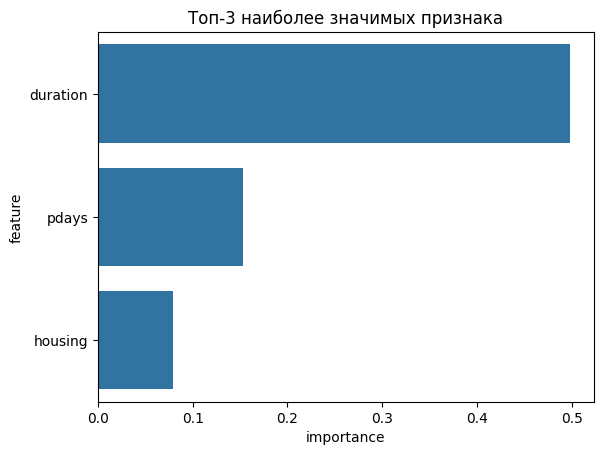

    feature  importance
7  duration    0.498354
9     pdays    0.153381
4   housing    0.079283


In [51]:
# Получаем важность признаков
importances = gb.feature_importances_
feature_names = X_train_final.columns

# Создаем датафрейм для визуализации
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(ascending=False, by='importance')

# Визуализация топ-3
sns.barplot(data=feature_importance_df.head(3), x='importance', y='feature')
plt.title('Топ-3 наиболее значимых признака')
plt.show()

print(feature_importance_df.head(3))


### Задания 6,7,8

In [52]:
import optuna
from sklearn.ensemble import RandomForestClassifier

# 1. Определяем функцию цели (objective function)
def objective(trial):
    # Задаем гиперпараметры для перебора
    n_estimators = trial.suggest_int('n_estimators', 100, 200, 1)
    max_depth = trial.suggest_int('max_depth', 10, 30, 1)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10, 1)

    # Создаем и обучаем модель
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    
    # Оцениваем на кросс-валидации (или на отложенной выборке)
    # Для Optuna обычно возвращают метрику, которую хотим максимизировать
    score = metrics.accuracy_score(y_train, model.predict(X_train_scaled))
    return score

# 2. Создаем исследование и запускаем оптимизацию
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20) # 20 итераций для примера

# 3. Обучаем лучшую модель с найденными параметрами
best_params = study.best_params
best_rf = RandomForestClassifier(**best_params, random_state=42)
best_rf.fit(X_train_scaled, y_train)

# 4. Считаем Accuracy на тесте
y_test_pred = best_rf.predict(X_test_scaled)
print(f"Accuracy на тестовой выборке: {round(metrics.accuracy_score(y_test, y_test_pred), 2)}")


[I 2026-04-27 13:04:54,211] A new study created in memory with name: no-name-9deb2f9c-95ec-4254-a03e-362e456ede8e
[I 2026-04-27 13:04:54,954] Trial 0 finished with value: 0.8536985402657045 and parameters: {'n_estimators': 133, 'max_depth': 14, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.8536985402657045.
[I 2026-04-27 13:04:55,918] Trial 1 finished with value: 0.9178284402164999 and parameters: {'n_estimators': 193, 'max_depth': 21, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.9178284402164999.
[I 2026-04-27 13:04:56,411] Trial 2 finished with value: 0.8745284566180088 and parameters: {'n_estimators': 118, 'max_depth': 25, 'min_samples_leaf': 6}. Best is trial 1 with value: 0.9178284402164999.
[I 2026-04-27 13:04:57,283] Trial 3 finished with value: 0.9557159258651796 and parameters: {'n_estimators': 183, 'max_depth': 24, 'min_samples_leaf': 2}. Best is trial 3 with value: 0.9557159258651796.
[I 2026-04-27 13:04:57,887] Trial 4 finished with value: 0.85271444972937

Accuracy на тестовой выборке: 0.82


# Финальные выводы и результаты исследования

## 1. Этап подготовки и очистки данных
* Была проведена комплексная очистка датасета: обработаны скрытые пропуски (`unknown`) и явные `NaN`.
* Признак `balance` был очищен от лишних символов и преобразован в числовой формат.
* С помощью метода Тьюки (межквартильный размах) были удалены аномальные значения в балансе, что позволило избежать искажения модели экстремально высокими показателями.
* Категориальные признаки были преобразованы с помощью `LabelEncoder` и `One-Hot Encoding` (дамми-переменные), что позволило использовать их в математических алгоритмах.

## 2. Разведывательный анализ (EDA)
* **Целевая аудитория:** Исследование показало, что наиболее лояльными группами являются студенты и пенсионеры. Также высокая конверсия наблюдается у клиентов с высшим образованием и неженатых/незамужних людей.
* **Важность прошлого опыта:** Клиенты, которые успешно открывали депозит в предыдущих кампаниях (`poutcome == success`), имеют максимально высокие шансы согласиться на предложение снова.
* **Фактор времени:** Длительность разговора (`duration`) оказалась самым сильным предиктором — чем дольше клиент готов общаться, тем выше вероятность сделки.

## 3. Сравнительный анализ моделей
В ходе работы были протестированы различные подходы:
* **Логистическая регрессия:** Хороший базовый уровень (Accuracy ~0.81), но уступает более сложным методам.
* **Решающие деревья:** Склонны к переобучению, требуют жесткого контроля глубины (оптимально — 6).
* **Случайный лес и Градиентный бустинг:** Показали лучшие результаты. Бустинг оказался наиболее эффективным инструментом для решения данной задачи классификации.
* **Оптимизация гиперпараметров:** Использование `Optuna` и `GridSearch` позволило найти наилучшие конфигурации моделей, увеличив их предсказательную способность и стабильность.

## 4. Рекомендации для бизнеса
1. **Таргетирование:** Рекомендуется сфокусировать маркетинговые бюджеты на сегменте клиентов с высшим образованием и тех, кто уже пользовался услугами банка ранее.
2. **Сезонное планирование:** Стоит пересмотреть стратегию звонков в мае (месяц с самым низким КПД) и усилить активность в начале весны и осенью.
3. **Обучение персонала:** Так как длительность звонка критически важна, стоит инвестировать в скрипты продаж, которые удерживают внимание клиента и вовлекают его в диалог.
